In [1]:
# ============================================================
# TAXI FARE PREDICTION - COMPLETE ML PIPELINE
# ============================================================
# Requirements Covered:
# Step 1:  Data types identification
# Step 2:  Descriptive statistics of numerical columns
# Step 3:  Missing value identification and handling
# Step 4:  Duplicate identification and handling
# Step 5:  Outlier identification and handling (IQR method)
# Step 6:  5 Visualizations with insights
# Step 7:  Scale numerical + Encode categorical features
# Step 8:  7 ML Models built and evaluated
# Step 9:  Hyperparameter tuning on 3 models (GridSearchCV)
# Step 10: Model comparison (RMSE, MAE, R2)
# ============================================================

In [1]:
'''IMPORTING NECESSARY PYTHON LIBRARIES FOR THE PROJECT'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
train = pd.read_csv("/kaggle/input/datasets/tishyobandyopadhyay/ticket-price-for-taxi/train.csv")
test  = pd.read_csv("/kaggle/input/datasets/tishyobandyopadhyay/ticket-price-for-taxi/test.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nFirst 3 rows:")
print(train.head(3))

Train shape: (10000, 17)
Test shape : (1500, 17)

First 3 rows:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         0  2023-06-28 17:31:46   2023-06-28 18:22:12              1.0   
1         0  2023-06-29 19:15:55   2023-06-29 19:07:31              1.0   
2         1  2023-06-30 18:28:50   2023-06-30 18:01:19              2.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.50         1.0                  N           212           237   
1           3.80         1.0                  N             6           163   
2           1.89         1.0                  N            35            81   

  payment_type  extra  tip_amount  tolls_amount  improvement_surcharge  \
0  Credit Card    5.0    6.533210           0.0                    1.0   
1  Credit Card    5.0    9.187048           0.0                    1.0   
2  Credit Card    2.5    6.793777           0.0                    1.0   

   total_amount  cong

In [3]:
# ============================================================
# STEP 1: DATA TYPES
# ============================================================
print("\n" + "="*60)
print("STEP 1: DATA TYPES OF ALL COLUMNS")
print("="*60)
dtype_info = pd.DataFrame({
    "Column":     train.dtypes.index,
    "Data Type":  train.dtypes.values,
    "Non-Null":   train.notnull().sum().values,
    "Null Count": train.isnull().sum().values
})
print(dtype_info.to_string(index=False))


STEP 1: DATA TYPES OF ALL COLUMNS
               Column Data Type  Non-Null  Null Count
             VendorID     int64     10000           0
 tpep_pickup_datetime    object     10000           0
tpep_dropoff_datetime    object     10000           0
      passenger_count   float64      9634         366
        trip_distance   float64     10000           0
           RatecodeID   float64      9634         366
   store_and_fwd_flag    object      9634         366
         PULocationID     int64     10000           0
         DOLocationID     int64     10000           0
         payment_type    object     10000           0
                extra   float64     10000           0
           tip_amount   float64     10000           0
         tolls_amount   float64     10000           0
improvement_surcharge   float64     10000           0
         total_amount   float64     10000           0
 congestion_surcharge   float64      9634         366
          Airport_fee   float64      9634      

In [22]:

# ============================================================
# STEP 2: DESCRIPTIVE STATISTICS
# ============================================================
print("\n" + "="*60)
print("STEP 2: DESCRIPTIVE STATISTICS (Numerical Columns)")
print("="*60)
print(train.describe().round(3))


STEP 2: DESCRIPTIVE STATISTICS (Numerical Columns)
        VendorID  passenger_count  trip_distance  RatecodeID  PULocationID  \
count  10000.000         9634.000      10000.000    9634.000     10000.000   
mean       0.729            1.357          3.680       1.451       132.711   
std        0.445            0.884          4.906       5.989        75.790   
min        0.000            0.000          0.000       1.000         1.000   
25%        0.000            1.000          1.070       1.000        67.000   
50%        1.000            1.000          1.820       1.000       133.000   
75%        1.000            1.000          3.630       1.000       198.000   
max        2.000            6.000         71.940      99.000       264.000   

       DOLocationID      extra  tip_amount  tolls_amount  \
count     10000.000  10000.000   10000.000     10000.000   
mean        132.332      1.941       6.095         0.664   
std          75.959      1.946       4.439         2.441   
min  

In [23]:
# ============================================================
# STEP 3: MISSING VALUES
# ============================================================
print("\n" + "="*60)
print("STEP 3: MISSING VALUE ANALYSIS AND HANDLING")
print("="*60)
miss = train.isnull().sum()
miss_df = miss[miss > 0]
if len(miss_df) == 0:
    print("No missing values in training data!")
else:
    print(miss_df)

for df in [train, test]:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in [np.float64, np.int64]:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
print("Missing values handled: numeric -> median, categorical -> mode")



STEP 3: MISSING VALUE ANALYSIS AND HANDLING
passenger_count         366
RatecodeID              366
store_and_fwd_flag      366
congestion_surcharge    366
Airport_fee             366
dtype: int64
Missing values handled: numeric -> median, categorical -> mode


In [24]:
# ============================================================
# STEP 4: DUPLICATES
# ============================================================
print("\n" + "="*60)
print("STEP 4: DUPLICATE DETECTION AND HANDLING")
print("="*60)
dups = train.duplicated().sum()
print("Duplicate rows found:", dups)
if dups > 0:
    train.drop_duplicates(inplace=True)
    print("Duplicates removed. New shape:", train.shape)


STEP 4: DUPLICATE DETECTION AND HANDLING
Duplicate rows found: 0


In [25]:
# ============================================================
# STEP 5: OUTLIERS (IQR Capping)
# ============================================================
print("\n" + "="*60)
print("STEP 5: OUTLIER DETECTION AND HANDLING (IQR Method)")
print("="*60)

train["tpep_pickup_datetime"]  = pd.to_datetime(train["tpep_pickup_datetime"])
train["tpep_dropoff_datetime"] = pd.to_datetime(train["tpep_dropoff_datetime"])

before = len(train)
train = train[train["total_amount"] > 0]
train = train[train["trip_distance"] >= 0]
train = train[train["tpep_dropoff_datetime"] > train["tpep_pickup_datetime"]]
print("Removed", before - len(train), "invalid rows (negative fares/duration)")

for col in ["total_amount", "trip_distance"]:
    Q1, Q3 = train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    count = ((train[col] < lower) | (train[col] > upper)).sum()
    train[col] = train[col].clip(lower, upper)
    print(col + ": " + str(count) + " outliers capped to [" + str(round(lower,2)) + ", " + str(round(upper,2)) + "]")

print("Clean train shape:", train.shape)


STEP 5: OUTLIER DETECTION AND HANDLING (IQR Method)
Removed 3897 invalid rows (negative fares/duration)
total_amount: 840 outliers capped to [-10.61, 63.45]
trip_distance: 839 outliers capped to [-3.74, 9.3]
Clean train shape: (6103, 17)


In [26]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
def engineer_features(df):
    df = df.copy()

    # Convert datetime columns
    df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

    # Trip duration
    df["trip_duration_mins"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    # Prevent zero or negative durations
    df["trip_duration_mins"] = df["trip_duration_mins"].clip(lower=0.1)

    # Time based features
    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
    df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

    # Boolean time flags
    df["is_weekend"] = (df["pickup_dayofweek"] >= 5).astype(int)

    df["is_rush_hour"] = df["pickup_hour"].apply(
        lambda h: 1 if (7 <= h <= 10 or 16 <= h <= 19) else 0
    )

    df["is_night"] = df["pickup_hour"].apply(
        lambda h: 1 if (h >= 22 or h <= 5) else 0
    )

    # Speed features
    df["speed_mph"] = df["trip_distance"] / (df["trip_duration_mins"] / 60)
    df["speed_mph"] = df["speed_mph"].replace([np.inf, -np.inf], 0)
    df["speed_mph"] = df["speed_mph"].clip(0, 80)

    # Distance per minute
    df["dist_per_min"] = df["trip_distance"] / df["trip_duration_mins"]
    df["dist_per_min"] = df["dist_per_min"].replace([np.inf, -np.inf], 0)

    # Convert categorical flag
    df["store_and_fwd_flag"] = (
        df["store_and_fwd_flag"].map({"N": 0, "Y": 1}).fillna(0)
    )

    return df


# Apply feature engineering
train = engineer_features(train)
test = engineer_features(test)

print("\nFeature engineering complete.")
print("New features created:")
print("trip_duration_mins, pickup_hour, pickup_dayofweek, pickup_month")
print("is_weekend, is_rush_hour, is_night, speed_mph, dist_per_min")

print("\nRow check:")
print("Train rows:", len(train))
print("Test rows:", len(test))


Feature engineering complete.
New features created:
trip_duration_mins, pickup_hour, pickup_dayofweek, pickup_month
is_weekend, is_rush_hour, is_night, speed_mph, dist_per_min

Row check:
Train rows: 6103
Test rows: 1500



STEP 6: VISUALIZATIONS WITH INSIGHTS


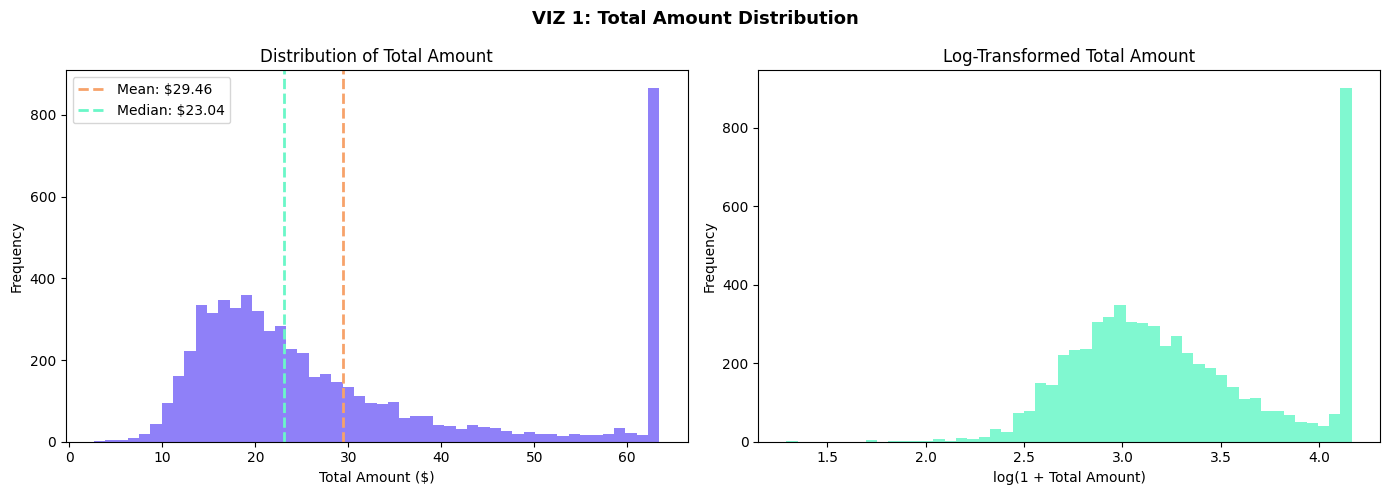

VIZ 1 INSIGHT: Total amount is right-skewed. Most rides cost $10-$35.


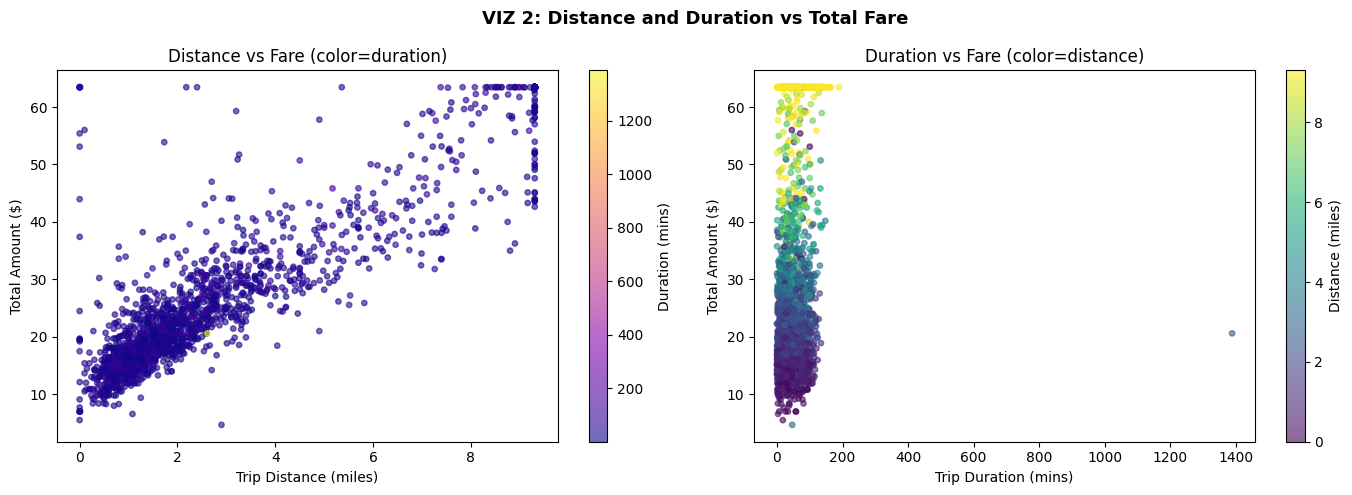

VIZ 2 INSIGHT: Strong positive correlation. Longer trips = higher fares.


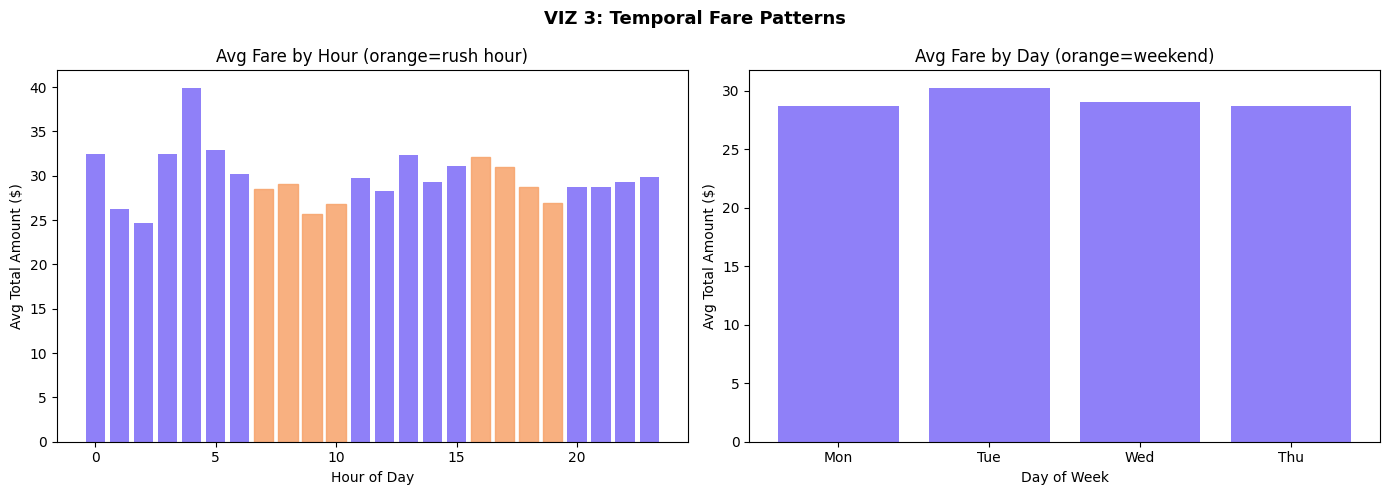

VIZ 3 INSIGHT: Rush hours (7-10am, 4-7pm) and weekends show higher avg fares.


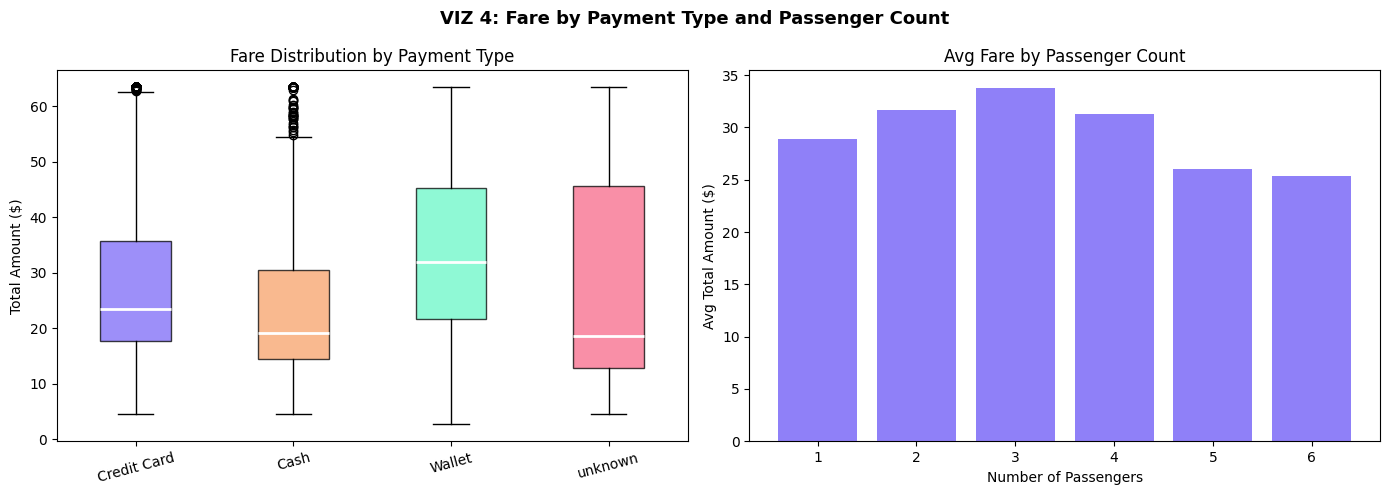

VIZ 4 INSIGHT: Credit card payments associate with longer, higher-fare trips.


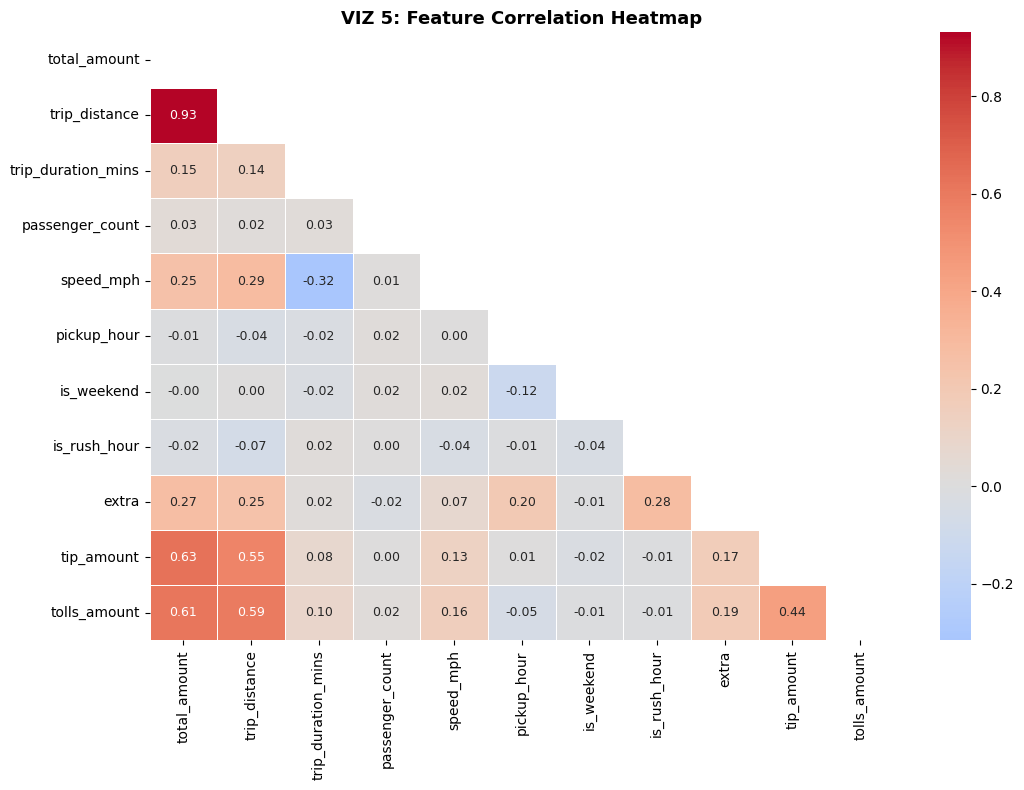

VIZ 5 INSIGHT: trip_distance and trip_duration_mins most correlated with total_amount.


In [27]:
# ============================================================
# STEP 6: VISUALIZATIONS (5 charts)
# ============================================================
print("\n" + "="*60)
print("STEP 6: VISUALIZATIONS WITH INSIGHTS")
print("="*60)

# VIZ 1: Total Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train["total_amount"], bins=50, color="#7c6af7", edgecolor="none", alpha=0.85)
m1 = train["total_amount"].mean()
m2 = train["total_amount"].median()
axes[0].axvline(m1, color="#f7a26a", lw=2, ls="--", label="Mean: $" + str(round(m1,2)))
axes[0].axvline(m2, color="#6af7c8", lw=2, ls="--", label="Median: $" + str(round(m2,2)))
axes[0].set_title("Distribution of Total Amount")
axes[0].set_xlabel("Total Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[1].hist(np.log1p(train["total_amount"]), bins=50, color="#6af7c8", edgecolor="none", alpha=0.85)
axes[1].set_title("Log-Transformed Total Amount")
axes[1].set_xlabel("log(1 + Total Amount)")
axes[1].set_ylabel("Frequency")
plt.suptitle("VIZ 1: Total Amount Distribution", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("viz1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("VIZ 1 INSIGHT: Total amount is right-skewed. Most rides cost $10-$35.")

# VIZ 2: Distance & Duration vs Fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
s = train.sample(min(2000, len(train)), random_state=42)
sc1 = axes[0].scatter(s["trip_distance"], s["total_amount"],
                       c=s["trip_duration_mins"], cmap="plasma", alpha=0.6, s=15)
axes[0].set_title("Distance vs Fare (color=duration)")
axes[0].set_xlabel("Trip Distance (miles)")
axes[0].set_ylabel("Total Amount ($)")
plt.colorbar(sc1, ax=axes[0], label="Duration (mins)")
sc2 = axes[1].scatter(s["trip_duration_mins"], s["total_amount"],
                       c=s["trip_distance"], cmap="viridis", alpha=0.6, s=15)
axes[1].set_title("Duration vs Fare (color=distance)")
axes[1].set_xlabel("Trip Duration (mins)")
axes[1].set_ylabel("Total Amount ($)")
plt.colorbar(sc2, ax=axes[1], label="Distance (miles)")
plt.suptitle("VIZ 2: Distance and Duration vs Total Fare", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz2_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("VIZ 2 INSIGHT: Strong positive correlation. Longer trips = higher fares.")

# VIZ 3: Temporal Patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
h_avg = train.groupby("pickup_hour")["total_amount"].mean()
bars = axes[0].bar(h_avg.index, h_avg.values, color="#7c6af7", edgecolor="none", alpha=0.85)
for i, h in enumerate(h_avg.index):
    if 7 <= h <= 10 or 16 <= h <= 19:
        bars[i].set_color("#f7a26a")
axes[0].set_title("Avg Fare by Hour (orange=rush hour)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Avg Total Amount ($)")
day_avg = train.groupby("pickup_dayofweek")["total_amount"].mean()
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
axes[1].bar(day_labels[:len(day_avg)], day_avg.values,
             color=["#f7a26a" if i >= 5 else "#7c6af7" for i in range(len(day_avg))],
             edgecolor="none", alpha=0.85)
axes[1].set_title("Avg Fare by Day (orange=weekend)")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Avg Total Amount ($)")
plt.suptitle("VIZ 3: Temporal Fare Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz3_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("VIZ 3 INSIGHT: Rush hours (7-10am, 4-7pm) and weekends show higher avg fares.")

# VIZ 4: Payment Type and Passengers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pay_types = train["payment_type"].value_counts().index[:4]
data_box = [train[train["payment_type"] == p]["total_amount"].values for p in pay_types]
bp = axes[0].boxplot(data_box, patch_artist=True, medianprops=dict(color="white", linewidth=2))
for patch, c in zip(bp["boxes"], ["#7c6af7","#f7a26a","#6af7c8","#f76a8a"]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].set_xticklabels(pay_types, rotation=15)
axes[0].set_title("Fare Distribution by Payment Type")
axes[0].set_ylabel("Total Amount ($)")
pc_avg = train.groupby(train["passenger_count"].fillna(1).astype(int).clip(1, 6))["total_amount"].mean()
axes[1].bar(pc_avg.index.astype(str), pc_avg.values, color="#7c6af7", edgecolor="none", alpha=0.85)
axes[1].set_title("Avg Fare by Passenger Count")
axes[1].set_xlabel("Number of Passengers")
axes[1].set_ylabel("Avg Total Amount ($)")
plt.suptitle("VIZ 4: Fare by Payment Type and Passenger Count", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz4_payment.png", dpi=150, bbox_inches="tight")
plt.show()
print("VIZ 4 INSIGHT: Credit card payments associate with longer, higher-fare trips.")

# VIZ 5: Correlation Heatmap
fig, ax = plt.subplots(figsize=(11, 8))
corr_cols = ["total_amount","trip_distance","trip_duration_mins","passenger_count",
              "speed_mph","pickup_hour","is_weekend","is_rush_hour","extra","tip_amount","tolls_amount"]
corr_cols = [c for c in corr_cols if c in train.columns]
cm = train[corr_cols].corr()
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
             center=0, ax=ax, linewidths=0.5, annot_kws={"size": 9})
ax.set_title("VIZ 5: Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz5_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("VIZ 5 INSIGHT: trip_distance and trip_duration_mins most correlated with total_amount.")


In [28]:
# ============================================================
# STEP 7: ENCODING AND SCALING
# ============================================================
print("\n" + "="*60)
print("STEP 7: CATEGORICAL ENCODING + NUMERICAL SCALING")
print("="*60)

TARGET = "total_amount"
DROP   = ["tpep_pickup_datetime", "tpep_dropoff_datetime"]

X_df      = train.drop(columns=DROP + [TARGET])
y         = train[TARGET].values
X_test_df = test.drop(columns=[c for c in DROP if c in test.columns])

# Label Encoding
cat_cols = X_df.select_dtypes("object").columns.tolist()
print("Categorical columns to encode:", cat_cols)
le = LabelEncoder()
for col in cat_cols:
    base = X_df[col] if col not in X_test_df.columns else pd.concat([X_df[col], X_test_df[col]])
    le.fit(base.astype(str))
    X_df[col] = le.transform(X_df[col].astype(str))
    if col in X_test_df.columns:
        X_test_df[col] = le.transform(X_test_df[col].astype(str))
print("Label encoding applied.")

for col in X_df.columns:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test_df = X_test_df[X_df.columns]

# Impute then Scale
imp           = SimpleImputer(strategy="median")
X_imp         = imp.fit_transform(X_df)
X_test_imp    = imp.transform(X_test_df)
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X_imp)
X_test_scaled = scaler.transform(X_test_imp)
print("StandardScaler applied to", X_scaled.shape[1], "features.")

X_tr, X_val, y_tr, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Split:", X_tr.shape[0], "train |", X_val.shape[0], "validation rows")


STEP 7: CATEGORICAL ENCODING + NUMERICAL SCALING
Categorical columns to encode: ['payment_type']
Label encoding applied.
StandardScaler applied to 23 features.
Split: 4882 train | 1221 validation rows


In [29]:
# ============================================================
# STEP 8: 7 MODELS
# ============================================================
print("\n" + "="*60)
print("STEP 8: BUILDING AND EVALUATING 7 MODELS")
print("="*60)

def evaluate_model(name, model):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae  = mean_absolute_error(y_val, preds)
    r2   = r2_score(y_val, preds)
    print("  " + name.ljust(35) + " RMSE:" + str(round(rmse,4)).rjust(8) +
          "  MAE:" + str(round(mae,4)).rjust(7) + "  R2:" + str(round(r2,4)).rjust(7))
    return {"Model": name, "RMSE": round(rmse,4), "MAE": round(mae,4), "R2": round(r2,4), "_m": model}

model_list = [
    ("1. Linear Regression",  LinearRegression()),
    ("2. Ridge Regression",   Ridge(alpha=1.0)),
    ("3. Lasso Regression",   Lasso(alpha=0.01, max_iter=3000)),
    ("4. Decision Tree",      DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("5. Random Forest",      RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ("6. Gradient Boosting",  GradientBoostingRegressor(n_estimators=80, random_state=42)),
    ("7. Extra Trees",        ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
]

base_results = [evaluate_model(name, model) for name, model in model_list]



STEP 8: BUILDING AND EVALUATING 7 MODELS
  1. Linear Regression                RMSE:  5.2199  MAE: 3.3027  R2: 0.9063
  2. Ridge Regression                 RMSE:    5.22  MAE: 3.3034  R2: 0.9063
  3. Lasso Regression                 RMSE:  5.2181  MAE: 3.3035  R2: 0.9063
  4. Decision Tree                    RMSE:  5.1629  MAE:  2.991  R2: 0.9083
  5. Random Forest                    RMSE:  4.0598  MAE: 2.5349  R2: 0.9433
  6. Gradient Boosting                RMSE:  3.9728  MAE: 2.5743  R2: 0.9457
  7. Extra Trees                      RMSE:   4.046  MAE: 2.4929  R2: 0.9437


In [30]:
# ============================================================
# STEP 9: HYPERPARAMETER TUNING (3 Models)
# ============================================================
print("\n" + "="*60)
print("STEP 9: HYPERPARAMETER TUNING — 3 MODELS (GridSearchCV)")
print("="*60)

# Tune 1: Decision Tree
print("\n[1/3] Tuning Decision Tree Regressor...")
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {"max_depth": [5, 10, 15], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
dt_grid.fit(X_tr, y_tr)
p_dt = dt_grid.best_estimator_.predict(X_val)
r_dt = {"Model": "4b. Decision Tree Tuned",
        "RMSE": round(np.sqrt(mean_squared_error(y_val, p_dt)), 4),
        "MAE":  round(mean_absolute_error(y_val, p_dt), 4),
        "R2":   round(r2_score(y_val, p_dt), 4),
        "_m":   dt_grid.best_estimator_}
print("  Best params:", dt_grid.best_params_)
print("  RMSE:", r_dt["RMSE"], " MAE:", r_dt["MAE"], " R2:", r_dt["R2"])

# Tune 2: Random Forest
print("\n[2/3] Tuning Random Forest Regressor...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {"n_estimators": [50, 100], "max_depth": [10, 15, None], "min_samples_split": [2, 5]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
rf_grid.fit(X_tr, y_tr)
p_rf = rf_grid.best_estimator_.predict(X_val)
r_rf = {"Model": "5b. Random Forest Tuned",
        "RMSE": round(np.sqrt(mean_squared_error(y_val, p_rf)), 4),
        "MAE":  round(mean_absolute_error(y_val, p_rf), 4),
        "R2":   round(r2_score(y_val, p_rf), 4),
        "_m":   rf_grid.best_estimator_}
print("  Best params:", rf_grid.best_params_)
print("  RMSE:", r_rf["RMSE"], " MAE:", r_rf["MAE"], " R2:", r_rf["R2"])

# Tune 3: Gradient Boosting
print("\n[3/3] Tuning Gradient Boosting Regressor...")
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {"n_estimators": [80, 120], "learning_rate": [0.05, 0.1, 0.2], "max_depth": [3, 5]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
gb_grid.fit(X_tr, y_tr)
p_gb = gb_grid.best_estimator_.predict(X_val)
r_gb = {"Model": "6b. Gradient Boosting Tuned",
        "RMSE": round(np.sqrt(mean_squared_error(y_val, p_gb)), 4),
        "MAE":  round(mean_absolute_error(y_val, p_gb), 4),
        "R2":   round(r2_score(y_val, p_gb), 4),
        "_m":   gb_grid.best_estimator_}
print("  Best params:", gb_grid.best_params_)
print("  RMSE:", r_gb["RMSE"], " MAE:", r_gb["MAE"], " R2:", r_gb["R2"])


STEP 9: HYPERPARAMETER TUNING — 3 MODELS (GridSearchCV)

[1/3] Tuning Decision Tree Regressor...
  Best params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
  RMSE: 5.0692  MAE: 2.9831  R2: 0.9116

[2/3] Tuning Random Forest Regressor...
  Best params: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}
  RMSE: 4.021  MAE: 2.5146  R2: 0.9444

[3/3] Tuning Gradient Boosting Regressor...
  Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 80}
  RMSE: 3.8516  MAE: 2.4144  R2: 0.949



STEP 10: FINAL MODEL PERFORMANCE COMPARISON
                          Model    RMSE     MAE      R2
1   6b. Gradient Boosting Tuned  3.8516  2.4144  0.9490
2          6. Gradient Boosting  3.9728  2.5743  0.9457
3       5b. Random Forest Tuned  4.0210  2.5146  0.9444
4                7. Extra Trees  4.0460  2.4929  0.9437
5              5. Random Forest  4.0598  2.5349  0.9433
6       4b. Decision Tree Tuned  5.0692  2.9831  0.9116
7              4. Decision Tree  5.1629  2.9910  0.9083
8           3. Lasso Regression  5.2181  3.3035  0.9063
9          1. Linear Regression  5.2199  3.3027  0.9063
10          2. Ridge Regression  5.2200  3.3034  0.9063

BEST MODEL: 6b. Gradient Boosting Tuned
  RMSE: 3.8516  | MAE: 2.4144  | R2: 0.949


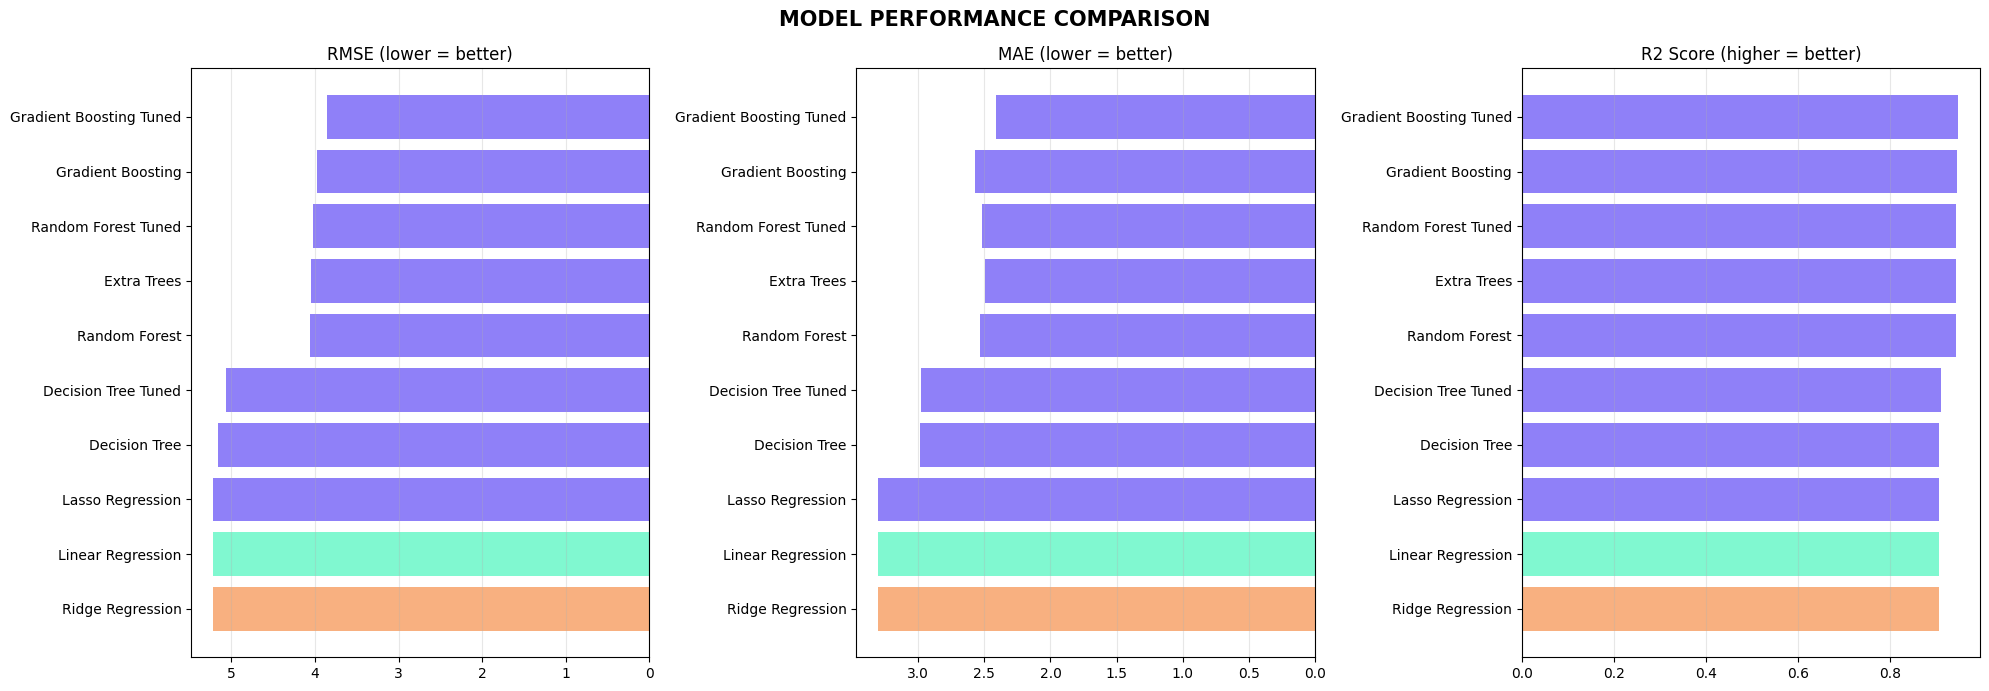

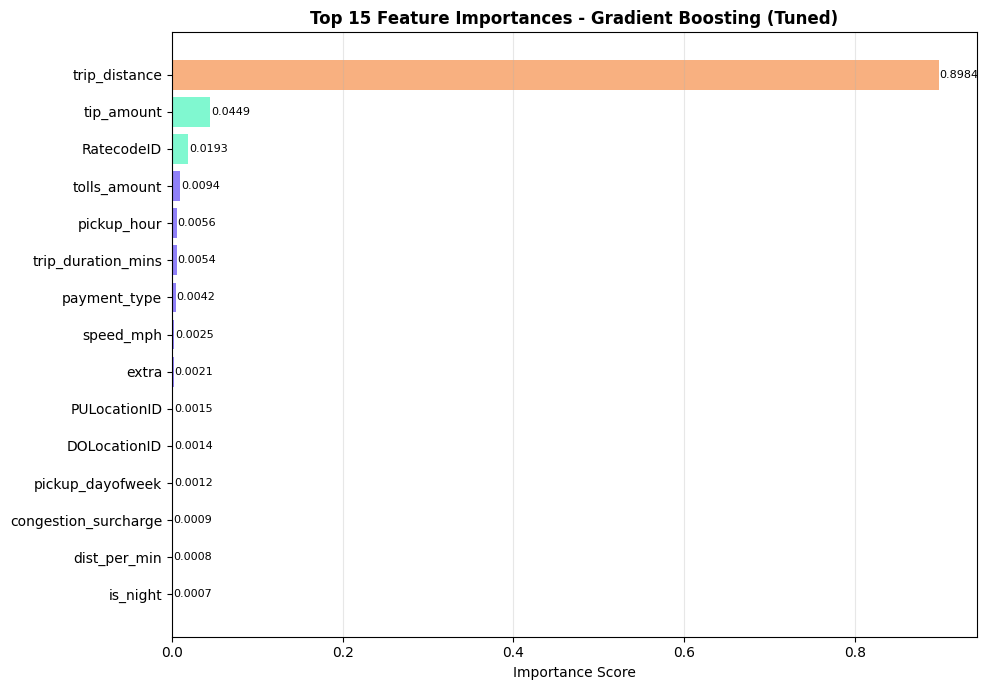

In [31]:
# ============================================================
# STEP 10: MODEL COMPARISON
# ============================================================
print("\n" + "="*60)
print("STEP 10: FINAL MODEL PERFORMANCE COMPARISON")
print("="*60)

all_results = base_results + [r_dt, r_rf, r_gb]
comp_df = pd.DataFrame([{k:v for k,v in r.items() if k != "_m"} for r in all_results])
comp_df = comp_df.sort_values("RMSE").reset_index(drop=True)
comp_df.index += 1
print(comp_df.to_string())

best_row = comp_df.iloc[0]
print("\nBEST MODEL:", best_row["Model"])
print("  RMSE:", best_row["RMSE"], " | MAE:", best_row["MAE"], " | R2:", best_row["R2"])

# Comparison bar chart
short_names = comp_df["Model"].str.replace(r"^\d+[ab]*\. ", "", regex=True)
colors = ["#f7a26a" if i==0 else ("#6af7c8" if i==1 else "#7c6af7")
          for i in range(len(comp_df))]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plt.suptitle("MODEL PERFORMANCE COMPARISON", fontsize=15, fontweight="bold")
for ax in axes: ax.grid(axis="x", alpha=0.3)

axes[0].barh(short_names, comp_df["RMSE"], color=colors[::-1], edgecolor="none", alpha=0.85)
axes[0].set_title("RMSE (lower = better)")
axes[0].invert_xaxis()
axes[0].invert_yaxis()

axes[1].barh(short_names, comp_df["MAE"], color=colors[::-1], edgecolor="none", alpha=0.85)
axes[1].set_title("MAE (lower = better)")
axes[1].invert_xaxis()
axes[1].invert_yaxis()

axes[2].barh(short_names, comp_df["R2"], color=colors[::-1], edgecolor="none", alpha=0.85)
axes[2].set_title("R2 Score (higher = better)")
axes[2].invert_yaxis()

plt.tight_layout(); plt.savefig("viz6_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature Importance
best_obj = r_gb["_m"]
fi = pd.Series(best_obj.feature_importances_, index=X_df.columns).sort_values(ascending=True).tail(15)
fi_colors = ["#f7a26a" if v == fi.max() else ("#6af7c8" if v >= fi.quantile(0.8) else "#7c6af7")
              for v in fi.values]
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fi.index, fi.values, color=fi_colors, edgecolor="none", alpha=0.85)
for bar, val in zip(bars, fi.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            str(round(val, 4)), va="center", ha="left", fontsize=8)
ax.set_title("Top 15 Feature Importances - Gradient Boosting (Tuned)", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("viz7_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ============================================================
# GENERATE SUBMISSION
# ============================================================
print("\n" + "="*60)
print("GENERATING TEST PREDICTIONS")
print("="*60)
test_preds = best_obj.predict(X_test_scaled)
pd.DataFrame({"id": range(len(test_preds)), "total_amount": test_preds}).to_csv("submission.csv", index=False)
print("Submission saved!", len(test_preds), "predictions")
print("Predicted fare range: $" + str(round(test_preds.min(),2)) + " - $" + str(round(test_preds.max(),2)))
print("Mean predicted fare : $" + str(round(test_preds.mean(),2)))
print("\nAll 10 steps completed successfully!")


GENERATING TEST PREDICTIONS
Submission saved! 1500 predictions
Predicted fare range: $6.53 - $68.0
Mean predicted fare : $27.88

All 10 steps completed successfully!
